In [1]:
# Cell 1: 安装依赖
!pip install librosa tqdm  # 安装音频处理库librosa和进度条库tqdm
print("✅ 依赖库安装完成！")  # 打印安装完成提示

Looking in indexes: http://pip.modelarts.private.com:8888/repository/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 44.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 25.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 kB 48.2 MB/s eta 0:00:00
✅ 依赖库安装完成！


In [2]:
# Cell 2: 数据搬运 (保持不变)
import moxing as mox  # 导入华为ModelArts的OBS文件操作库
import os             # 导入操作系统模块
import time           # 导入时间模块，用于计算耗时

OBS_PATH = "obs://bullying2/raw_data"  # OBS云存储中原始数据路径
LOCAL_PATH = "/cache/dataset"          # 本地缓存目录

if not os.path.exists(LOCAL_PATH):  # 若本地目录不存在
    os.makedirs(LOCAL_PATH)         # 则创建该目录

print(f"🚀 正在从 {OBS_PATH} 下载数据...")  # 打印下载开始提示
start = time.time()  # 记录开始时间

try:
    mox.file.copy_parallel(OBS_PATH, LOCAL_PATH)                       # 并行下载OBS数据到本地
    print(f"✅ 下载完成！耗时: {time.time() - start:.2f} 秒")      # 打印下载耗时
    print("📂 本地目录检查:", os.listdir(LOCAL_PATH))          # 列出本地文件验证下载结果
except Exception as e:  # 捕获所有异常并打印错误信息
    print(f"❌ 下载失败: {e}")  # 打印异常错误信息

/home/ma-user/anaconda3/envs/MindSpore/lib/python3.11/site-packages/moxing/framework/version.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO:root:Using MoXing-v2.3.11-8a68d29b
INFO:root:Using OBS-Python-SDK-3.25.3
INFO:root:Using OBS-C-SDK-2.23.1


🚀 正在从 obs://bullying2/raw_data 下载数据...


INFO:root:Multiprocessing connection patch for bpo-17560 not applied, not an applicable Python version: 3.11.10 (main, Oct  3 2024, 07:21:51) [GCC 11.2.0]
INFO:root:List OBS time cost: 1.13 seconds.
INFO:root:Copy parallel total time cost: 238.56 seconds.


✅ 下载完成！耗时: 238.56 秒
📂 本地目录检查: ['MMFi_Dataset', 'MIVIA_DB4_dist']


In [ ]:
import os  # 导入操作系统接口模块
import glob  # 导入文件路径批量匹配模块
import numpy as np  # 导入数值计算库NumPy，别名np
import zipfile  # 导入ZIP文件处理模块

# ========== 从OBS下载MMFi zip文件（OBS不存在则跳过）==========
MMFi_OBS = 'obs://bullying2/raw_data/MMFi_Dataset/Zipfiles'  # MMFi zip在OBS上的路径
MMFi_AVAILABLE = False
try:
    import moxing as mox
    if not os.path.exists('/cache/MMFi_Zipfiles') or len(glob.glob('/cache/MMFi_Zipfiles/S*.zip')) == 0:
        print('正在从OBS下载MMFi zip文件...')
        os.makedirs('/cache/MMFi_Zipfiles', exist_ok=True)
        mox.file.copy_parallel(MMFi_OBS, '/cache/MMFi_Zipfiles')
        print('MMFi zip下载完成')
    else:
        print('MMFi zip已存在本地缓存，跳过下载')
    MMFi_AVAILABLE = len(glob.glob('/cache/MMFi_Zipfiles/S*.zip')) > 0
except Exception as e:
    print(f'MMFi OBS下载失败，跳过雷达真实数据: {e.__class__.__name__}')


# ========== 配置 ==========
ZIP_DIR    = '/cache/MMFi_Zipfiles'   # S01-S40 zip 所在目录
EXTRACT_DIR = '/cache/MMFi_extracted'  # 解压目标目录路径
OUTPUT_DIR  = '/home/ma-user/work/Ascend_Processed_Data'  # 最终数据输出目录路径
os.makedirs(EXTRACT_DIR, exist_ok=True)  # 创建解压目录，若已存在则跳过

# 解压 zip
for zf in sorted(glob.glob(os.path.join(ZIP_DIR, 'S01.zip'))):  # 只解压S01.zip
    with zipfile.ZipFile(zf) as z:  # 以只读方式打开ZIP压缩文件
        z.extractall(EXTRACT_DIR)  # 将ZIP内容解压到指定目录
    print(f'解压: {os.path.basename(zf)}')  # 打印当前正在解压的文件名

# 动作标签
ACTION_LABELS = {  # 定义动作ID到标签的映射字典
    # 霸凌代理动作: 投掷(左/右)A20/A21、踢腿(左/右)A22/A23
    'A20': 1, 'A21': 1, 'A22': 1, 'A23': 1,
    # 正常动作: 胸廓扩张A02/A03、扭转A04/A05、弓步A09/A10
    'A02': 0, 'A03': 0, 'A04': 0, 'A09': 0, 'A10': 0, 'A11': 0,
}

def read_bin(path):  # 定义读取雷达二进制点云文件的函数
    try:
        data = np.fromfile(path, dtype=np.float32)  # 以float32格式读取整个二进制文件
        if len(data) % 5 != 0:  # 检查数据总量是否为5的整数倍（每点5属性）
            return None  # 格式不符合则返回None
        pts = data.reshape(-1, 5)  # (N, 5): x,y,z,doppler,SNR  # 重塑为(N,5)点云矩阵
        if len(pts) == 0:  # 检查点云是否为空
            return None  # 格式不符合则返回None
        # 截断或补零到64点
        if len(pts) >= 64:  # 若点数>=64则截断
            pts = pts[:64]  # 只保留前64个点
        else:
            pad = np.zeros((64 - len(pts), 5), dtype=np.float32)  # 创建补零行以凑足64点
            pts = np.concatenate([pts, pad], axis=0)  # 将原始点云与零填充拼接
        return pts.T  # (5, 64)  # 转置为(5,64)后返回，行=通道，列=点
    except Exception:  # 捕获所有文件读取异常
        return None  # 格式不符合则返回None

# 找到所有受试者目录 S01-S40并排序
subject_dirs = sorted(glob.glob(os.path.join(EXTRACT_DIR, 'S*')))  # 找到所有受试者目录并排序
print(f'共找到 {len(subject_dirs)} 个受试者目录')  # 打印受试者目录数量

radar_X, radar_y = [], []  # 初始化雷达特征和标签列表
for act, lbl in ACTION_LABELS.items():  # 遍历每个动作标签
    files = []  # 初始化当前动作的文件路径列表
    for s_dir in subject_dirs:  # 遍历每个受试者目录
        files += glob.glob(os.path.join(s_dir, '**', act, 'mmwave', '*.bin'), recursive=True)  # 递归查找该动作的所有雷达bin文件
    print(f'   -> {act}: {len(files)} 帧')  # 打印当前动作找到的帧数
    for f in files:  # 遍历每个雷达帧文件
        pc = read_bin(f)  # 调用函数读取点云数据
        if pc is None:  # 若读取失败则跳过
            continue  # 继续处理下一个文件
        radar_X.append(pc)  # 将点云加入特征列表
        radar_y.append(lbl)  # 将对应标签加入标签列表

if radar_X:  # 若成功收集到点云数据
    np.save(os.path.join(OUTPUT_DIR, 'radar_X.npy'), np.stack(radar_X).astype(np.float32))  # 将雷达特征堆叠保存为npy文件
    np.save(os.path.join(OUTPUT_DIR, 'radar_y.npy'), np.array(radar_y, dtype=np.int32))  # 将标签保存为int32 npy文件
    labels = np.array(radar_y)  # 将标签列表转换为numpy数组
    print(f'雷达: {len(radar_X)} 个样本，维度: 5 (x, y, z, doppler, SNR)')  # 打印雷达样本总数及通道说明
    print(f'   正常(0): {(labels==0).sum()}, 霸凌(1): {(labels==1).sum()}')  # 打印正常与霸凌样本数量
    print(f'数据已保存至: {OUTPUT_DIR}')  # 打印数据保存路径
else:
    print('未找到数据，请检查 ZIP_DIR 路径和文件结构')  # 提示用户检查路径配置

# ========== Sim-to-Real 仿真管道 ==========
import librosa  # 导入音频特征提取库librosa

def sim_radar_noise(points, drop_rate=0.4, noise_count=5, target_n=64):  # 定义雷达点云仿真噪声增强函数
    # points: (N, 5)  x,y,z,doppler,SNR
    # 1. 去质心+单位球归一化
    centroid = points[:, :3].mean(axis=0)  # 计算xyz坐标的质心
    points[:, :3] -= centroid  # 去质心，将点云平移到原点
    scale = np.abs(points[:, :3]).max() + 1e-8  # 计算最大绝对坐标值作为缩放因子（+1e-8防除零）
    points[:, :3] /= scale  # 将xyz坐标归一化到[-1,1]范围
    # 2. 随机丢点 -- 模拟RS6240稀疏输出
    keep = np.random.rand(len(points)) > drop_rate  # 生成随机掩码，以drop_rate概率丢弃点（模拟稀疏输出）
    points = points[keep]  # 按掩码过滤，去除被丢弃的点
    # 3. 鬼影点注入 -- 模拟多径反射
    ghost = np.random.uniform(-1, 1, (noise_count, 5)).astype(np.float32)  # 生成随机鬼影点，模拟多径反射干扰
    ghost[:, 3] = np.random.normal(0, 0.5, noise_count)  # 随机多普勒  # 给鬼影点设置随机多普勒速度
    ghost[:, 4] = np.random.uniform(0, 0.2, noise_count)  # 低SNR  # 给鬼影点设置低信噪比值
    points = np.vstack([points, ghost]) if len(points) > 0 else ghost  # 将鬼影点加入点云（空点云直接用鬼影点）
    # 4. 固定尺寸: 采样或零填充到 target_n
    n = len(points)  # 获取当前点云总点数
    if n >= target_n:  # 若点数超过目标数量则下采样
        idx = np.random.choice(n, target_n, replace=False)  # 随机无放回地选取target_n个点的索引
        return points[idx].astype(np.float32)  # 返回下采样后的点云（float32）
    else:
        pad = np.zeros((target_n - n, 5), dtype=np.float32)  # 创建补零矩阵以凑足目标点数
        return np.vstack([points, pad]).astype(np.float32)  # 拼接补零后返回固定尺寸点云


def sim_audio_augment(waveform, sr=16000, rir_wav=None, bg_wav=None,  # 定义音频仿真增强函数，支持RIR混响、背景噪声混合和梅尔频谱提取
                      snr_db=None, n_mels=64, n_frames=128):  # 传入snr_db、梅尔频带数n_mels和目标帧数n_frames参数
    # waveform: 1D numpy float32
    # 1. RIR混响卷积 (若提供RIR)
    if rir_wav is not None:  # 若提供RIR冲激响应则对音频进行混响卷积
        import scipy.signal  # 导入scipy信号处理模块（仅在需要时导入）
        waveform = scipy.signal.fftconvolve(waveform, rir_wav, mode="full")[:len(waveform)]  # 用FFT卷积添加混响效果，截断到原始长度
    # 2. 背景噪声混合 (随机SNR)
    if bg_wav is not None:  # 若提供背景噪声则进行混合
        snr = snr_db if snr_db is not None else np.random.choice([0, 5, 10])  # 随机选取目标SNR（0/5/10 dB）或使用指定值
        sig_pow = np.mean(waveform ** 2) + 1e-9  # 计算信号功率（+1e-9防除零）
        noise_len = len(waveform)  # 获取需要截取的背景噪声长度
        start = np.random.randint(0, max(1, len(bg_wav) - noise_len))  # 随机选取背景噪声的起始位置
        bg = bg_wav[start:start + noise_len]  # 截取对应长度的背景噪声片段
        if len(bg) < noise_len:  # 若背景噪声不足则在末尾补零
            bg = np.pad(bg, (0, noise_len - len(bg)))  # 在背景噪声末尾补零到目标长度
        bg_pow = np.mean(bg ** 2) + 1e-9  # 计算背景噪声功率
        scale = np.sqrt(sig_pow / (bg_pow * (10 ** (snr / 10))))  # 按目标SNR计算噪声缩放系数
        waveform = waveform + scale * bg  # 将缩放后的背景噪声叠加到信号上
    # 3. 转梅尔频谱图 (1, n_mels, n_frames)
    hop = sr // (n_frames - 1) if n_frames > 1 else 160  # 计算梅尔频谱的帧移hop_length
    mel = librosa.feature.melspectrogram(y=waveform.astype(np.float32), sr=sr,  # 调用librosa计算梅尔频谱图
                                          n_mels=n_mels, hop_length=hop,  # 传入梅尔频带数和帧移参数
                                          n_fft=400)  # 传入FFT窗长n_fft=400
    mel_db = librosa.power_to_db(mel, ref=np.max)  # 将梅尔功率谱转换为分贝刻度（以最大值为参考）
    # 固定到 (n_mels, n_frames)
    if mel_db.shape[1] < n_frames:  # 若梅尔频谱帧数不足则在时间轴末尾补零
        mel_db = np.pad(mel_db, ((0,0),(0, n_frames - mel_db.shape[1])))  # 在时间轴末尾补零到n_frames帧
    else:
        mel_db = mel_db[:, :n_frames]  # 截断到目标帧数n_frames
    return mel_db[np.newaxis, :, :].astype(np.float32)  # (1, 64, 128)


# ========== 批量生成仿真数据并保存 ==========
def build_sim_dataset(radar_npy_path=None, audio_wav_dir=None,  # 定义批量生成仿真数据集的函数
                      out_dir="/home/ma-user/work/Ascend_Processed_Data",  # 指定仿真数据输出目录
                      n_sim=400, drop_rate=0.4, sr=16000):  # 传入仿真样本数、丢点率和采样率参数
    import os  # 导入操作系统接口模块
    os.makedirs(out_dir, exist_ok=True)  # 创建输出目录，若已存在则跳过
    N = n_sim  # 设置仿真样本总数
    audio_mels = []  # 初始化音频梅尔频谱列表
    radar_pcs  = []  # 初始化雷达点云列表
    labels     = []  # 初始化标签列表
    print(f"生成 {N} 条仿真样本 (drop_rate={drop_rate})...")  # 打印开始生成的提示信息
    for i in range(N):  # 逐条生成仿真样本
        label = 1 if i < N // 4 else 0  # 25% 欺凌样本
        # --- 雷达仿真 ---
        if radar_npy_path and os.path.exists(radar_npy_path):  # 若提供了真实雷达npy文件则循环读取
            raw_pc = np.load(radar_npy_path)[i % len(np.load(radar_npy_path))]  # 循环索引读取真实雷达点云帧
        else:
            # 无真实数据: 根据label生成合理形状
            n_pts = np.random.randint(20, 120)  # 随机生成20~120个点的合成点云
            if label == 1:  # 霸凌样本生成较大运动幅度的点云
                raw_pc = np.random.randn(n_pts, 5).astype(np.float32) * 0.5  # 霸凌：高斯点云乘以0.5，模拟较大运动幅度
                raw_pc[:, 3] = np.random.uniform(0.3, 1.5, n_pts)  # 高多普勒
            else:
                raw_pc = np.random.randn(n_pts, 5).astype(np.float32) * 0.2  # 正常：高斯点云乘以0.2，模拟小幅度运动
                raw_pc[:, 3] = np.random.uniform(-0.1, 0.3, n_pts)  # 低多普勒
        sim_pc = sim_radar_noise(raw_pc, drop_rate=drop_rate)  # (64, 5)
        radar_pcs.append(sim_pc.T)  # 转为 (5, 64)
        # --- 音频仿真 ---
        duration = 1.0  # 设置音频片段时长为1秒
        if label == 1:  # 霸凌样本生成高能量谐波音频
            # 模拟欺凌: 高能量突发 + 谐波
            t = np.linspace(0, duration, int(sr * duration))  # 生成时间轴数组
            freq = np.random.choice([300, 500, 800, 1200])  # 随机选取基频（300/500/800/1200 Hz）
            wave = (0.6 * np.sin(2 * np.pi * freq * t)  # 生成基频正弦波（幅度0.6）
                    + 0.3 * np.sin(2 * np.pi * freq * 2 * t)  # 叠加二次谐波（幅度0.3）
                    + 0.1 * np.random.randn(len(t))).astype(np.float32)  # 叠加高斯噪声（幅度0.1），模拟实际声音
        else:
            # 模拟正常: 低能量环境音
            wave = (np.random.randn(int(sr * duration)) * 0.05).astype(np.float32)  # 正常：低能量高斯白噪声模拟环境背景音
        mel = sim_audio_augment(wave, sr=sr)  # (1, 64, 128)
        audio_mels.append(mel)  # 将生成的梅尔频谱追加到列表
        labels.append(label)  # 将对应标签追加到列表
    audio_mels = np.stack(audio_mels)  # (N, 1, 64, 128)
    radar_pcs  = np.stack(radar_pcs)   # (N, 5, 64)
    labels     = np.array(labels, dtype=np.int32)  # 将标签列表转换为int32 numpy数组
    idx = np.random.permutation(N)  # 生成随机置换索引，用于打乱数据顺序
    audio_mels, radar_pcs, labels = audio_mels[idx], radar_pcs[idx], labels[idx]  # 按随机索引打乱音频、雷达和标签数组
    np.save(os.path.join(out_dir, "audio_mel.npy"), audio_mels)  # 将音频梅尔频谱保存为npy文件
    np.save(os.path.join(out_dir, "radar_X.npy"),   radar_pcs)  # 将雷达点云保存为npy文件
    np.save(os.path.join(out_dir, "radar_y.npy"),   labels)  # 将标签保存为npy文件
    print(f"保存完成: {out_dir}")  # 打印保存完成提示
    print(f"  audio_mel: {audio_mels.shape}  radar_X: {radar_pcs.shape}  labels: {labels.shape}")  # 打印各数组的shape信息
    pos = (labels==1).sum()  # 统计霸凌正例数量
    print(f"  欺凌样本: {pos}  正常样本: {N-pos}")  # 打印正负样本数量分布
    return audio_mels, radar_pcs, labels  # 返回音频、雷达和标签数组

print("========== Sim-to-Real 管道测试 ==========")  # 打印Sim-to-Real管道测试分隔线
audio_mels, radar_pcs, labels = build_sim_dataset(n_sim=400, drop_rate=0.4)  # 调用build_sim_dataset生成400条仿真数据
print(f"仿真数据集准备完成，共 {len(labels)} 条样本")  # 打印仿真数据集准备完成信息


# ========== AudioSet 真实音频接入（替换 MIVIA）==========
# 使用 download_audioset_subset.py 预下载的 AudioSet 霸凌子集
# 标签: Screaming, Crying/sobbing, Shout, Slap/smack 等 → 霸凌正例
#        Speech, Laughter, Chatter, Music → 正常负例
import librosa

AUDIOSET_DIR = '/home/ma-user/work/audioset_bullying'  # AudioSet 子集目录
AUDIOSET_OBS = 'obs://bullying2/audioset_bullying'     # OBS 备份路径

# 尝试从 OBS 下载（ModelArts 环境）
if not os.path.exists(os.path.join(AUDIOSET_DIR, 'audio_mel.npy')):
    try:
        import moxing as mox
        print(f'正在从 {AUDIOSET_OBS} 下载 AudioSet 子集...')
        os.makedirs(AUDIOSET_DIR, exist_ok=True)
        mox.file.copy_parallel(AUDIOSET_OBS, AUDIOSET_DIR)
        print('AudioSet 子集下载完成')
    except Exception as e:
        print(f'AudioSet OBS 下载失败: {e}')
        print('请先在本地运行: python download_audioset_subset.py --output-dir', AUDIOSET_DIR)
else:
    print('AudioSet 子集已存在本地缓存，跳过下载')

# 加载预处理好的 AudioSet 梅尔频谱
try:
    audioset_audio = np.load(os.path.join(AUDIOSET_DIR, 'audio_mel.npy'))   # (N, 1, 64, 128)
    audioset_labels = np.load(os.path.join(AUDIOSET_DIR, 'audio_labels.npy'))  # (N,)
    print(f'AudioSet: {len(audioset_labels)} 帧 | 欺凌:{(audioset_labels==1).sum()} 正常:{(audioset_labels==0).sum()}')
except FileNotFoundError:
    print('AudioSet 数据未找到，使用仿真数据作为音频源')
    audioset_audio = audio_mels    # fallback 到仿真数据
    audioset_labels = labels

# ===== 与雷达数据按 label 对齐随机配对 =====
def merge_audio_with_radar(audio_arr, audio_labels, radar_npy_dir=OUTPUT_DIR):
    try:
        rX = np.load(os.path.join(radar_npy_dir, 'radar_X.npy'))  # (M, 5, 64)
        ry = np.load(os.path.join(radar_npy_dir, 'radar_y.npy'))
        print(f'配对 MMFi 雷达: {len(ry)} 帧')
    except FileNotFoundError:
        rX = np.random.randn(len(audio_labels), 5, 64).astype(np.float32)
        ry = audio_labels.copy()
        print('未找到 MMFi 雷达，使用仿真雷达配对')
    merged_a, merged_r, merged_l = [], [], []
    for lbl in [0, 1]:
        a_idx = np.where(audio_labels == lbl)[0]
        r_idx = np.where(ry == lbl)[0]
        n = min(len(a_idx), len(r_idx))
        if n == 0:
            continue
        np.random.shuffle(a_idx)
        np.random.shuffle(r_idx)
        for i in range(n):
            merged_a.append(audio_arr[a_idx[i]])
            merged_r.append(rX[r_idx[i]])
            merged_l.append(lbl)
    ma = np.stack(merged_a).astype(np.float32)
    mr = np.stack(merged_r).astype(np.float32)
    ml = np.array(merged_l, dtype=np.int32)
    idx = np.random.permutation(len(ml))
    return ma[idx], mr[idx], ml[idx]

as_a, as_r, as_l = merge_audio_with_radar(audioset_audio, audioset_labels)
print(f'AudioSet 配对后: {len(as_l)} 条 | 欺凌:{(as_l==1).sum()} 正常:{(as_l==0).sum()}')

# ===== 最终合并：仿真数据 + AudioSet 真实音频 =====
final_audio  = np.concatenate([audio_mels, as_a], axis=0)
final_radar  = np.concatenate([radar_pcs,  as_r], axis=0)
final_labels = np.concatenate([labels,     as_l], axis=0)
idx = np.random.permutation(len(final_labels))
final_audio, final_radar, final_labels = final_audio[idx], final_radar[idx], final_labels[idx]
np.save(os.path.join(OUTPUT_DIR, 'audio_mel.npy'), final_audio)
np.save(os.path.join(OUTPUT_DIR, 'radar_X.npy'),   final_radar)
np.save(os.path.join(OUTPUT_DIR, 'radar_y.npy'),   final_labels)
print(f'最终数据集: {len(final_labels)} 条 | 欺凌:{(final_labels==1).sum()} 正常:{(final_labels==0).sum()}')
print('数据已覆盖写入 audio_mel.npy / radar_X.npy / radar_y.npy')

MMFi zip已存在本地缓存，跳过下载
解压: S01.zip
共找到 20 个受试者目录
   -> A20: 5940 帧
   -> A21: 5940 帧
   -> A22: 5940 帧
   -> A23: 5643 帧
   -> A02: 5940 帧
   -> A03: 5940 帧
   -> A04: 5940 帧
   -> A09: 5940 帧
   -> A10: 5940 帧
   -> A11: 5940 帧
雷达: 58811 个样本，维度: 5 (x, y, z, doppler, SNR)
   正常(0): 35372, 霸凌(1): 23439
数据已保存至: /home/ma-user/work/Ascend_Processed_Data
========== Sim-to-Real 管道测试 ==========
生成 400 条仿真样本 (drop_rate=0.4)...
保存完成: /home/ma-user/work/Ascend_Processed_Data
  audio_mel: (400, 1, 64, 128)  radar_X: (400, 5, 64)  labels: (400,)
  欺凌样本: 100  正常样本: 300
仿真数据集准备完成，共 400 条样本
MIVIA 已存在本地缓存，跳过下载
加载 MIVIA DB4 音频数据...
  加载 200/528 个wav文件 (正:100 负:100)
  加载 158/232 个wav文件 (正:100 负:58)
MIVIA training: 73248 帧 | 欺凌:36658 正常:36590
MIVIA testing:  56854 帧 | 欺凌:36358 正常:20496
配对MMFi雷达: 400 帧
MIVIA合并后: 400 条 | 欺凌:100 正常:300
最终数据集: 800 条 | 欺凌:200 正常:600
数据已覆盖写入 audio_mel.npy / radar_X.npy / radar_y.npy


In [17]:
# Cell 4: 模型架构 v3 - AudioCNN + RadarPointNet(T-Net) + GRU时序 + MindCMA
import mindspore  # 导入华为昇思MindSpore深度学习框架
import mindspore.nn as nn  # 导入神经网络模块，别名nn
import mindspore.ops as ops  # 导入MindSpore算子库，别名ops
from mindspore import context, Tensor  # 导入上下文配置和张量类
import numpy as np  # 导入NumPy数值计算库

context.set_context(mode=context.GRAPH_MODE, device_target="Ascend")  # 设置静态图模式并指定运行在昇腾NPU上

# ===== 音频分支: 4层CNN -> 256维 =====
class AudioMelCNNBranch(nn.Cell):  # 定义音频梅尔频谱CNN分支网络类
    def __init__(self):  # 初始化网络层结构
        super().__init__()  # 调用父类Cell的初始化方法
        self.conv = nn.SequentialCell([  # 定义4层CNN卷积序列，提取梅尔频谱的层级特征
            nn.Conv2d(1,  32,3,pad_mode="same"),nn.BatchNorm2d(32), nn.ReLU(),nn.MaxPool2d(2,2),  # 第1层：1->32通道，3x3卷积+BN+ReLU+2x2最大池化
            nn.Conv2d(32, 64,3,pad_mode="same"),nn.BatchNorm2d(64), nn.ReLU(),nn.MaxPool2d(2,2),  # 第2层：32->64通道，3x3卷积+BN+ReLU+2x2最大池化
            nn.Conv2d(64,128,3,pad_mode="same"),nn.BatchNorm2d(128),nn.ReLU(),nn.MaxPool2d(2,2),  # 第3层：64->128通道，3x3卷积+BN+ReLU+2x2最大池化
            nn.Conv2d(128,256,3,pad_mode="same"),nn.BatchNorm2d(256),nn.ReLU(),nn.MaxPool2d(2,2),  # 第4层：128->256通道，3x3卷积+BN+ReLU+2x2最大池化
        ])  # 结束SequentialCell定义
        self.gap = nn.AdaptiveAvgPool2d((1,1))  # 全局自适应平均池化，输出(1,1)大小
        self.flat= nn.Flatten()  # 将多维特征图展平为一维向量
        self.fc  = nn.SequentialCell([nn.Dense(256,256),nn.ReLU(),nn.Dropout(p=0.3)])  # 全连接：256->256维，ReLU激活，Dropout防过拟合
    def construct(self,x): return self.fc(self.flat(self.gap(self.conv(x))))  # 前向传播：卷积->全局池化->展平->全连接

# ===== T-Net: 输入变换网络 =====
class TNet(nn.Cell):  # 定义T-Net输入变换网络，学习点云空间变换矩阵
    def __init__(self, k=5):  # 初始化T-Net，k为点云通道数（5维）
        super().__init__()  # 调用父类Cell的初始化方法
        self.k = k  # 保存通道维度k
        self.mlp = nn.SequentialCell([  # 定义T-Net特征变换MLP：逐点卷积提取全局特征
            nn.Conv1d(k,  64,1),nn.BatchNorm1d(64), nn.ReLU(),  # 第1层逐点卷积：k->64通道+BN+ReLU
            nn.Conv1d(64,128,1),nn.BatchNorm1d(128),nn.ReLU(),  # 第2层逐点卷积：64->128通道+BN+ReLU
            nn.Conv1d(128,256,1),nn.BatchNorm1d(256),nn.ReLU(),  # 第3层逐点卷积：128->256通道+BN+ReLU
        ])  # 结束MLP SequentialCell定义
        self.fc = nn.SequentialCell([nn.Dense(256,128),nn.ReLU(),nn.Dense(128,k*k)])  # 全连接层：256->128->k*k，输出变换矩阵参数
        self.pool= nn.AdaptiveMaxPool1d(1)  # 自适应最大池化，聚合全局点特征
        self.flat= nn.Flatten()  # 将多维特征图展平为一维向量
    def construct(self,x):  # 前向传播
        B = x.shape[0]  # 获取batch大小
        feat = self.flat(self.pool(self.mlp(x)))  # 经MLP提取特征后全局最大池化再展平
        mat  = self.fc(feat).view(B, self.k, self.k)  # 全连接输出reshape为kxk变换矩阵
        eye  = ops.eye(self.k, self.k, mindspore.float32).unsqueeze(0).broadcast_to((B,-1,-1))  # 生成单位矩阵并扩展到batch维度，作为残差基础
        return mat + eye  # 返回残差变换矩阵（初始接近单位矩阵）

# ===== RadarPointNet: TNet + PointNet全局MaxPool -> 128维 + 独立雷达头 =====
class RadarPointNet(nn.Cell):  # 定义雷达PointNet网络：TNet变换+PointNet全局特征提取
    def __init__(self):  # 初始化网络层结构
        super().__init__()  # 调用父类Cell的初始化方法
        self.tnet = TNet(k=5)  # 实例化T-Net（5通道：x,y,z,doppler,SNR）
        self.mlp1 = nn.SequentialCell([  # 第一阶段MLP：逐点卷积提取局部特征
            nn.Conv1d(5, 64,1),nn.BatchNorm1d(64),nn.ReLU(),  # 第1层：5->64通道逐点卷积+BN+ReLU
            nn.Conv1d(64,64,1),nn.BatchNorm1d(64),nn.ReLU(),  # 第2层：64->64通道逐点卷积+BN+ReLU
        ])  # 结束第一阶段MLP定义
        self.mlp2 = nn.SequentialCell([  # 第二阶段MLP：提取高维特征
            nn.Conv1d(64,128,1),nn.BatchNorm1d(128),nn.ReLU(),  # 第1层：64->128通道逐点卷积+BN+ReLU
            nn.Conv1d(128,256,1),nn.BatchNorm1d(256),nn.ReLU(),  # 第3层逐点卷积：128->256通道+BN+ReLU
        ])  # 结束第二阶段MLP SequentialCell定义
        self.pool    = nn.AdaptiveMaxPool1d(1)  # 全局最大池化，提取点云全局最显著特征
        self.flat    = nn.Flatten()  # 定义Flatten层，将多维特征图展平为一维向量
        self.feat_fc = nn.SequentialCell([  # 定义特征全连接层序列
            nn.Dense(256,128),nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(p=0.3)  # Dense(256->128)+BN+ReLU+Dropout(0.3)的特征变换
        ])  # 结束feat_fc SequentialCell定义
        self.radar_head = nn.SequentialCell([nn.Dense(128,64),nn.ReLU(),nn.Dense(64,2)])  # 独立雷达分类头：128->64->2维
    def construct(self,x):  # 前向传播
        T_mat = self.tnet(x)  # 通过T-Net计算空间变换矩阵
        x     = ops.bmm(T_mat, x)  # 对点云施加变换（批量矩阵乘法）
        x     = self.mlp1(x)  # 第一MLP提取64维局部特征
        x     = self.mlp2(x)  # 第二MLP提取256维高层特征
        feat  = self.feat_fc(self.flat(self.pool(x)))  # 全局最大池化->展平->全连接得128维全局特征
        return feat, self.radar_head(feat)  # 返回128维全局特征和2维雷达分类logits

# ===== MindCMA: 跨模态注意力融合 =====
class MindCMA(nn.Cell):  # 定义跨模态注意力融合模块(Cross-Modal Attention)
    def __init__(self, audio_dim=256, radar_dim=128, unified=128):  # 初始化CMA：音频256维、雷达128维统一映射到128维
        super().__init__()  # 调用父类Cell的初始化方法
        self.ap   = nn.SequentialCell([nn.Dense(audio_dim,unified),nn.Tanh()])  # 音频投影层：256->128维，Tanh激活
        self.rp   = nn.SequentialCell([nn.Dense(radar_dim, unified),nn.Tanh()])  # 雷达投影层：128->128维，Tanh激活
        self.attn = nn.SequentialCell([nn.Dense(unified*2,64),nn.ReLU(),nn.Dense(64,1)])  # 注意力权重网络：256->64->1维标量权重
        self.sig  = nn.Sigmoid()  # Sigmoid将注意力权重归一化到[0,1]
    def construct(self,af,rf):  # 前向传播：af=音频特征，rf=雷达特征
        ap=self.ap(af); rp=self.rp(rf)  # 分别投影音频和雷达特征到统一空间
        alpha=self.sig(self.attn(ops.concat([ap,rp],1)))  # 拼接投影特征后计算动态注意力权重alpha
        return alpha*ap+(1-alpha)*rp, alpha  # 按alpha加权融合两路特征并返回权重

# ===== GRU时序上下文: 真正多帧建模 =====
class GRUTemporalCtx(nn.Cell):  # 定义GRU时序上下文模块，对多帧特征建模
    def __init__(self, input_dim=128, hidden=64):  # 初始化GRU：输入128维，隐状态64维
        super().__init__()  # 调用父类Cell的初始化方法
        self.gru = nn.GRU(input_size=input_dim,hidden_size=hidden,batch_first=True)  # GRU层，batch_first=True表示输入为(B,T,dim)
    def construct(self, x, h_prev=None):  # 支持跨窗口 hidden state 传递
        if h_prev is None:
            out, h_next = self.gru(x)
        else:
            out, h_next = self.gru(x, h_prev)
        return out[:, -1, :], h_next  # (B, hidden), (1, B, hidden)

# ===== AscendSentinel2 v3: 统一多帧接口, 无重复计算 =====
# 输入: audio(B,T,1,64,128)  radar(B,T,5,64)
# 输出: main_logits(B,2), audio_logits(B,2), radar_logits(B,2), alpha(B,1), h_next(1,B,64)
T_FRAMES = 4  # 时序帧数：每次输入连续4帧进行建模

class AscendSentinel2(nn.Cell):  # 主模型：多模态多帧霸凌检测网络v3
    def __init__(self, t_frames=T_FRAMES):  # 初始化主模型，t_frames为时序帧数
        super().__init__()  # 调用父类Cell的初始化方法
        self.T   = t_frames  # 保存帧数T
        self.ab  = AudioMelCNNBranch()  # 实例化音频CNN分支
        self.rb  = RadarPointNet()  # 实例化雷达PointNet分支
        self.cma_seq = MindCMA()  # 用于时序融合(GRU输入)
        self.cma_cls = MindCMA()  # 用于最终帧分类判决
        self.gru = GRUTemporalCtx(input_dim=128, hidden=64)  # GRU时序建模模块
        self.audio_head = nn.SequentialCell([nn.Dense(256,64),nn.ReLU(),nn.Dense(64,2)])  # 音频独立分类头：256->64->2维
        self.clf = nn.SequentialCell([  # 定义主分类头：多层全连接网络
            nn.Dense(576,256),nn.BatchNorm1d(256),nn.ReLU(),nn.Dropout(p=0.5),  # Dense(576->256)+BN+ReLU+Dropout(0.5)的第一分类层
            nn.Dense(256,128),nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(p=0.3),
            nn.Dense(128,64), nn.ReLU(),
            nn.Dense(64,2)
        ])

    def construct(self, audio, radar, h_prev=None):  # 主前向传播函数，h_prev 用于跨窗口 GRU 状态传递
        # audio: (B,T,1,64,128)  radar: (B,T,5,64)
        # --- 展平时间维批量处理, 避免Python for循环 ---
        B, T = audio.shape[0], self.T  # 获取batch大小B和帧数T
        # reshape: (B*T, 1, 64, 128) 和 (B*T, 5, 64)
        a_flat = audio.view(B*T, 1, 64, 128)  # 展平时间维，批量处理B*T帧音频
        r_flat = radar.view(B*T, 5, 64)  # 展平时间维，批量处理B*T帧雷达
        # 批量前向
        af_flat = self.ab(a_flat)                    # (B*T, 256)
        rf_flat, rl_flat = self.rb(r_flat)           # (B*T, 128), (B*T, 2)
        fused_flat, _ = self.cma_seq(af_flat, rf_flat)  # (B*T, 128)
        # reshape回时间维
        fused_seq = fused_flat.view(B, T, 128)       # (B, T, 128)
        # GRU时序建模
        tc, h_next = self.gru(fused_seq, h_prev)     # (B, 64), (1, B, 64)
        # 取最后帧用于分类
        af_last = af_flat.view(B, T, 256)[:, T-1, :]  # (B, 256)
        rf_last = rf_flat.view(B, T, 128)[:, T-1, :]  # (B, 128)
        rl_last = rl_flat.view(B, T, 2)[:, T-1, :]    # (B, 2)
        fused_last, alpha = self.cma_cls(af_last, rf_last) # (B,128),(B,1)
        # 主分类头
        feat = ops.concat([fused_last, tc, af_last, rf_last], 1)  # (B,576)
        main_logits  = self.clf(feat)  # 主分类头输出2维logits
        audio_logits = self.audio_head(af_last)  # 音频分支独立分类logits
        return main_logits, audio_logits, rl_last, alpha, h_next  # 返回主/音频/雷达logits、注意力权重和GRU隐状态

print("AscendSentinel2 v3 架构:")
print(f"  输入: audio(B,{T_FRAMES},1,64,128) + radar(B,{T_FRAMES},5,64)")
print(f"  批量展平: B*T同时处理, 无Python for循环, GRAPH_MODE兼容")
print(f"  音频CNN: 256d + 独立音频头(2cls)")
print(f"  雷达PointNet+TNet: 128d + 独立雷达头(2cls)")
print(f"  MindCMA: alpha加权融合 -> 128d")
print(f"  GRU({T_FRAMES}帧): 真正多帧时序 -> 64d")
print(f"  主头: 576d -> 2cls")
print(f"  联合损失: main + 0.3*audio + 0.3*radar")


[WARNING] ME(4754:281473362263072,MainProcess):2026-03-25-16:47:03.789.000 [mindspore/run_check/_check_version.py:409] Can not find the tbe operator implementation(need by mindspore-ascend). Please check whether the Environment Variable PYTHONPATH is set. For details, refer to the installation guidelines: https://www.mindspore.cn/install
[WARNING] ME(4754:281473362263072,MainProcess):2026-03-25-16:47:03.790.000 [mindspore/context.py:1418] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.
[WARNING] ME(4754:281473362263072,MainProcess):2026-03-25-16:47:03.792.000 [mindspore/run_check/_check_version.py:409] Can not find the tbe operator implementation(need by mindspore-ascend). Please check whether the Environment Variable PYTHONPATH is set. For details, refer to the installation guidelines: https://www.mindspore.cn/install


AscendSentinel2 v3 架构:
  输入: audio(B,4,1,64,128) + radar(B,4,5,64)
  批量展平: B*T同时处理, 无Python for循环, GRAPH_MODE兼容
  音频CNN: 256d + 独立音频头(2cls)
  雷达PointNet+TNet: 128d + 独立雷达头(2cls)
  MindCMA: alpha加权融合 -> 128d
  GRU(4帧): 真正多帧时序 -> 64d
  主头: 576d -> 2cls
  联合损失: main + 0.3*audio + 0.3*radar


In [ ]:
# Cell 5: 数据集(无泄露滑窗) + 联合损失训练
import os, numpy as np, mindspore, mindspore.nn as nn, mindspore.ops as ops  # 导入os、numpy、mindspore及其nn/ops子模块
from mindspore import Tensor  # 从mindspore导入Tensor类
from mindspore.dataset import GeneratorDataset  # 从mindspore.dataset导入GeneratorDataset

# ===== Focal Loss (Softmax, 2-class, 按类别分配 alpha) =====
class FocalLoss(nn.Cell):  # 定义Focal Loss类，继承MindSpore Cell
    def __init__(self, alpha_pos=0.75, alpha_neg=0.25, gamma=2.0):  # alpha_pos=正例(霸凌)权重, alpha_neg=负例(正常)权重
        super().__init__()  # 调用父类Cell初始化方法
        self.alpha_pos = alpha_pos  # 正例(霸凌)类别权重，数据集中正例占少数，给更高权重
        self.alpha_neg = alpha_neg  # 负例(正常)类别权重
        self.gamma = gamma  # 保存gamma参数（难例聚焦指数）
        self.softmax = nn.Softmax(axis=1)  # 创建Softmax层，用于将logits转为概率
        self.ce = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="none")  # 创建带Softmax的交叉熵损失，sparse=True表示标签为整数
    def construct(self, logits, labels):  # 前向计算：输入logits(B,2)和整数标签(B,)，返回标量损失
        # logits: (B,2)  labels: (B,) int32
        ce_loss = self.ce(logits, labels)          # (B,)
        p_t = self.softmax(logits)                 # (B,2)
        # p_t for the true class
        lf = labels.astype(mindspore.int32)  # 将标签转换为int32类型以兼容one_hot算子
        one_hot = ops.one_hot(lf, 2, Tensor(1.0), Tensor(0.0))  # (B,2)
        pt = (p_t * one_hot).sum(axis=1)  # (B,)
        # 按类别分配 alpha: 正例(label=1)用 alpha_pos, 负例(label=0)用 alpha_neg
        alpha_t = labels.astype(mindspore.float32) * self.alpha_pos + (1 - labels.astype(mindspore.float32)) * self.alpha_neg
        focal_w = alpha_t * ops.pow(1 - pt, self.gamma)  # focal权重 = alpha_t * (1-pt)^gamma
        return (focal_w * ce_loss).mean()  # 返回focal加权损失的均值

# ===== 无泄露多帧滑窗数据集 =====
class MultiFrameDataset:  # 定义无泄露多帧滑窗数据集类，先切分帧再做滑窗
    # 关键修复: 先按帧序列切分train/val, 再各自做滑窗
    # train帧: [0, split_n)  val帧: [split_n, N)
    # 这样train窗口和val窗口不共享任何帧, 无数据泄露
    def __init__(self, audio, radar, labels, T=4):  # 初始化多帧数据集：传入音频/雷达/标签数组和帧数T
        self.T = T  # 保存时序帧数T
        self.audio  = audio   # (N,1,64,128)
        self.radar  = radar   # (N,5,64)
        self.labels = labels  # (N,)
        N = len(labels)  # 获取总帧数N
        # 滑窗: 步长=1, label=窗口最后帧
        self.windows = [(i, i+T) for i in range(0, N-T+1)]  # 生成所有长度为T的滑窗(起始,终止)索引对
        pos = sum(labels[e-1]==1 for _,e in self.windows)  # 统计正例（霸凌）窗口数量
        print(f"  {len(self.windows)}窗口 | 欺凌:{pos} 正常:{len(self.windows)-pos}")  # 打印当前集合的窗口总数及正负样本分布
    def __len__(self): return len(self.windows)  # 返回数据集样本总数
    def __getitem__(self, i):  # 按索引获取一条多帧样本
        s,e = self.windows[i]  # 取出第i个滑窗的起止索引
        a = self.audio[s:e].copy()   # (T,1,64,128)
        r = self.radar[s:e].copy()   # (T,5,64)
        # 音频增强
        for t in range(self.T):  # 遍历窗口内每一帧做SpecAugment数据增强
            tm=np.random.randint(0,21)  # 随机生成时间掩码宽度（0~20帧）
            if tm>0:  # 若掩码宽度>0则执行时间掩码
                t0=np.random.randint(0,128-tm); a[t,0,:,t0:t0+tm]=0  # 随机选取掩码起始位置并将该区域置零
            fm=np.random.randint(0,11)  # 随机生成频率掩码高度（0~10梅尔频带）
            if fm>0:  # 若掩码高度>0则执行频率掩码
                f0=np.random.randint(0,64-fm); a[t,0,f0:f0+fm,:]=0  # 随机选取频率掩码起始位置并将该区域置零
        # 雷达抖动增强
        if np.random.rand()<0.5:  # 以50%概率对雷达点云施加随机抖动增强
            r[:,:3]+=np.random.randn(*r[:,:3].shape).astype(np.float32)*0.05  # 给雷达xyz坐标加入均值为0、标准差0.05的高斯噪声
        # 模态 dropout: 训练时随机丢弃一路，让模型适应单模态降级推理
        if np.random.rand() < 0.15:
            r = np.zeros_like(r)   # 15% 概率丢弃雷达 → 模型学会 audio-only
        elif np.random.rand() < 0.15:
            a = np.zeros_like(a)   # 15% 概率丢弃音频 → 模型学会 radar-only
        return a.astype(np.float32), r.astype(np.float32), np.int32(self.labels[e-1])  # 返回增强后的音频、雷达数据和窗口末帧标签

def load_or_sim(data_dir, n_sim=400):  # 尝试加载真实数据，失败则生成模拟数据
    try:  # 尝试从磁盘加载真实数据
        audio  = np.load(os.path.join(data_dir,"audio_mel.npy"))  # 从本地目录加载音频梅尔频谱npy文件
        radar  = np.load(os.path.join(data_dir,"radar_X.npy"))  # 从本地目录加载雷达点云npy文件
        labels = np.load(os.path.join(data_dir,"radar_y.npy"))  # 从本地目录加载标签npy文件
        print(f"加载真实数据: {len(labels)} 帧")  # 打印真实数据加载成功信息
    except FileNotFoundError:  # 捕获文件未找到异常，切换到模拟数据
        print("未找到数据，使用模拟数据")  # 提示用户数据文件不存在，使用随机模拟数据代替
        N=n_sim  # 设置模拟数据总条数
        audio  = np.random.randn(N,1,64,128).astype(np.float32)  # 生成随机模拟音频梅尔频谱（高斯分布）
        radar  = np.random.randn(N,5,64).astype(np.float32)  # 生成随机模拟雷达点云（高斯分布）
        labels = np.array([1]*int(N*0.25)+[0]*int(N*0.75),dtype=np.int32)  # 生成25%霸凌75%正常的标签数组
        np.random.shuffle(labels)  # 随机打乱标签顺序
    return audio, radar, labels  # 返回音频、雷达和标签数组

# ===== 关键: 先按帧切分, 再建各自数据集 =====
DATA_DIR = "/home/ma-user/work/Ascend_Processed_Data"  # 指定数据目录路径
T_FRAMES = 4  # 设置时序帧数为4帧
TRAIN_RATIO = 0.8  # 设置训练集占比为80%
BATCH    = 16  # 设置批大小为16
EPOCHS   = 100  # 设置总训练轮数为100
WARMUP   = 5  # 设置学习率热身轮数为5
LR       = 1e-3  # 设置初始学习率为1e-3

audio_all, radar_all, labels_all = load_or_sim(DATA_DIR)  # 加载或生成全部数据
N = len(labels_all)  # 获取总样本帧数
split_n = int(N * TRAIN_RATIO)  # 按比例计算训练集帧数分割点
print(f"帧切分: train[0:{split_n}] val[{split_n}:{N}] (无帧重叠)")  # 打印帧切分信息，确认无帧重叠

print("TRAIN:", end=" ")  # 打印训练集构建开始标志
train_raw = MultiFrameDataset(audio_all[:split_n], radar_all[:split_n], labels_all[:split_n], T=T_FRAMES)  # 用前split_n帧构建训练集多帧数据集
print("VAL:",   end=" ")  # 打印验证集构建开始标志
val_raw   = MultiFrameDataset(audio_all[split_n:], radar_all[split_n:], labels_all[split_n:], T=T_FRAMES)  # 用剩余帧构建验证集多帧数据集

train_ds = GeneratorDataset(train_raw,["audio","radar","label"],shuffle=True).batch(BATCH,drop_remainder=True)  # 将训练集包装为MindSpore GeneratorDataset并打乱后批处理
steps    = max(len(train_raw)//BATCH, 1)  # 计算每个epoch的训练步数

# ===== LR Schedule =====
def build_lr(base_lr, warmup_ep, total_ep, steps_per_ep):  # 定义余弦退火+线性热身学习率调度函数
    lrs=[]; ws=warmup_ep*steps_per_ep; ts=total_ep*steps_per_ep  # 初始化学习率列表和热身/总步数
    for s in range(ts):  # 逐步生成每个训练步的学习率值
        if s<ws: lr=base_lr*(s+1)/ws  # 热身阶段：学习率从0线性增长到base_lr
        else:  # 余弦退火阶段
            p=(s-ws)/max(ts-ws,1)  # 计算余弦退火阶段的进度比例p
            lr=base_lr*0.01+0.5*base_lr*0.99*(1+np.cos(np.pi*p))  # 余弦退火：从base_lr衰减到base_lr*0.01
        lrs.append(lr)  # 将当前步学习率加入列表
    return lrs  # 返回完整学习率列表

lr_list = build_lr(LR, WARMUP, EPOCHS, steps)  # 生成完整的学习率调度列表
net     = AscendSentinel2(t_frames=T_FRAMES)  # 实例化主检测网络AscendSentinel2
loss_fn = FocalLoss(alpha_pos=0.75, alpha_neg=0.25, gamma=2.0)  # Focal Loss: 正例(霸凌)权重0.75, 负例(正常)权重0.25
opt     = nn.Adam(net.trainable_params(),  # 创建Adam优化器，使用动态学习率和权重衰减
                  learning_rate=Tensor(np.array(lr_list,np.float32)),  # 传入动态学习率张量
                  weight_decay=1e-4)  # 设置权重衰减（L2正则化系数）

# ===== 联合训练步 =====
class JointTrainStep(nn.Cell):  # 定义联合训练步，封装前向+梯度+参数更新
    def __init__(self, net, opt, loss_fn, w_aux=0.3):  # 初始化训练步：网络、优化器、损失函数和辅助损失权重
        super().__init__(auto_prefix=False)  # 调用父类初始化，auto_prefix=False避免参数名重复
        self.net=net; self.opt=opt; self.loss_fn=loss_fn; self.w=w_aux  # 保存网络、优化器、损失函数和辅助权重
        self.grad_fn=mindspore.value_and_grad(self._fwd,None,opt.parameters)  # 创建自动微分函数，计算前向值和梯度
    def _fwd(self,audio,radar,label):  # 定义前向计算：主损失+辅助音频损失+辅助雷达损失
        ml,al,rl,_,_=self.net(audio,radar)  # 前向推理获取主/音频/雷达logits（忽略alpha和h_next）
        return self.loss_fn(ml,label)+self.w*self.loss_fn(al,label)+self.w*self.loss_fn(rl,label)  # 返回加权联合损失
    def construct(self,audio,radar,label):  # 定义MindSpore图模式训练步：计算梯度并更新参数
        loss,grads=self.grad_fn(audio,radar,label)  # 执行前向和反向传播，获取损失值和梯度
        self.opt(grads); return loss  # 应用梯度更新参数，返回当前步损失值

trainer = JointTrainStep(net, opt, loss_fn, w_aux=0.3)  # 实例化联合训练步对象
trainer.set_train()  # 将训练步设置为训练模式
val_ds = GeneratorDataset(val_raw, ["audio","radar","label"], shuffle=False).batch(BATCH, drop_remainder=False)  # 将验证集包装为MindSpore GeneratorDataset
print("="*70)  # 打印分隔线
print(f"联合训练: main+0.3*audio+0.3*radar | Focal Loss alpha_pos=0.75 | T={T_FRAMES}帧 | batch={BATCH} | steps={steps}")  # 打印联合训练配置信息
print("="*70)  # 打印分隔线

def val_f1(net):  # 定义验证函数，计算精确率/召回率/F1分数
    net.set_train(False)  # 切换网络为推理模式（关闭Dropout和BatchNorm更新）
    sm = mindspore.ops.Softmax(axis=1)  # 创建Softmax算子，对logits做概率归一化
    tp=tn=fp=fn=0  # 初始化混淆矩阵四项计数器为0
    for batch in val_ds.create_tuple_iterator():  # 遍历验证集所有批次
        a,r,l = batch  # 解包批次数据为音频/雷达/标签
        ml,_,_,_,_ = net(a, r)  # 前向推理，只取主分类logits
        preds = sm(ml).asnumpy()[:,1] >= 0.5  # 对主logits做Softmax后取霸凌概率，≥0.5判为正例
        lbls  = l.asnumpy()  # 将标签张量转为numpy数组
        for p,g in zip(preds, lbls):  # 遍历预测结果和真实标签对，更新混淆矩阵
            if g==1 and p: tp+=1  # 真正例：标签为霸凌且预测为霸凌
            elif g==0 and not p: tn+=1  # 真负例：标签为正常且预测为正常
            elif g==0 and p: fp+=1  # 假正例：标签为正常但预测为霸凌
            else: fn+=1  # 假负例：标签为霸凌但预测为正常
    prec = tp/(tp+fp+1e-8); rec = tp/(tp+fn+1e-8)  # 计算精确率和召回率（+1e-8防除零）
    f1 = 2*prec*rec/(prec+rec+1e-8)  # 计算F1分数（精确率和召回率的调和平均）
    net.set_train(True)  # 恢复网络为训练模式
    return f1, prec, rec  # 返回F1、精确率、召回率

best_f1 = 0.0  # 初始化最优F1为0
for ep in range(1,EPOCHS+1):  # 逐epoch执行训练循环
    losses=[]  # 初始化当前epoch的损失列表
    for batch in train_ds.create_tuple_iterator():  # 遍历训练集所有批次
        a,r,l=batch; losses.append(float(trainer(a,r,l).asnumpy()))  # 执行一步训练并记录损失值
    ml=np.mean(losses)  # 计算当前epoch的平均训练损失
    if ep%5==0 or ep==1:  # 每5个epoch或第1个epoch时进行验证
        f1, prec, rec = val_f1(net)  # 调用验证函数计算当前epoch的F1等指标
        cur_lr=lr_list[min((ep-1)*steps,len(lr_list)-1)]  # 获取当前epoch对应的学习率值
        print(f"Epoch[{ep:3d}/{EPOCHS}] loss={ml:.4e} lr={cur_lr:.2e} val_F1={f1:.3f} P={prec:.3f} R={rec:.3f}")  # 打印当前epoch的训练状态信息
        if f1 > best_f1:  # 若当前F1优于历史最优则更新
            best_f1 = f1  # 更新最优F1记录
            mindspore.save_checkpoint(net,"/home/ma-user/work/sentinel_best.ckpt")  # 保存当前最优模型权重到ckpt文件
            print(f"  => best ckpt saved (F1={best_f1:.3f})")
print("训练完成")
mindspore.save_checkpoint(net,"/home/ma-user/work/sentinel_final.ckpt")  # 训练结束后保存最终权重文件

In [21]:
# Cell 6: 验证 + 修正后融合三级报警
import numpy as np, mindspore  # 导入numpy和mindspore模块
from mindspore import Tensor  # 从mindspore导入Tensor类

net.set_train(False)  # 将网络切换到推理模式（关闭Dropout）
softmax = mindspore.ops.Softmax(axis=1)  # 创建Softmax算子，对logits进行概率归一化

def predict_window(ds, win_idx):  # 定义单窗口预测函数，返回主/音频/雷达概率、注意力权重和真实标签
    a, r, lbl = ds[win_idx]  # 从验证集取出指定窗口的音频、雷达和标签
    a_t = Tensor(a[np.newaxis])   # (1,T,1,64,128)
    r_t = Tensor(r[np.newaxis])   # (1,T,5,64)
    main_l, audio_l, radar_l, alpha, _ = net(a_t, r_t)  # 前向推理获取主、音频、雷达分类logits和注意力权重（忽略h_next）
    p_main  = float(softmax(main_l).asnumpy()[0,1])  # 取主分类头霸凌概率（类别1的Softmax输出）
    p_audio = float(softmax(audio_l).asnumpy()[0,1])   # 真实模型输出
    p_radar = float(softmax(radar_l).asnumpy()[0,1])   # 真实模型输出
    al = float(alpha.asnumpy()[0,0])  # 取注意力权重alpha的标量值
    return p_main, p_audio, p_radar, al, int(lbl)  # 返回主/音频/雷达概率、注意力权重和真实标签

def estimate_snr(mel_window):  # 定义SNR估计函数：用梅尔频谱高频带/低频带能量比估计信噪比
    # mel_window: (T,1,64,128) 梅尔频谱
    # SNR估计: 高频带(32:64)能量 / 低频带(0:8)背景能量
    mel = mel_window[:, 0, :, :]   # (T,64,128)
    signal_pow = float(np.mean(mel[:, 32:, :] ** 2)) + 1e-9  # 计算高频带(32:64梅尔频带)信号功率作为信号能量估计
    noise_pow  = float(np.mean(mel[:,  :8, :] ** 2)) + 1e-9  # 计算低频带(0:8梅尔频带)能量作为背景噪声估计
    snr_db = 10 * np.log10(signal_pow / noise_pow)  # 计算信噪比（dB）= 10*log10(信号功率/噪声功率）
    return float(np.clip(snr_db, 0, 30))  # 将SNR限制在[0,30]dB范围后返回

def estimate_radar_density(radar_window):  # 定义雷达点云密度估计函数，用SNR通道有效点比例衡量密度
    # radar_window: (T,5,64)  SNR通道在索引4
    snr_ch = radar_window[:, 4, :]   # (T,64)
    density = float((snr_ch > 0.05).mean())  # 计算SNR>0.05的有效点占比作为密度指标
    return density  # 返回点云密度值

# ===== 修正后融合: 用真实模型p_audio和p_radar =====
class LateAlertFusion:  # 定义后融合三级报警类，动态权重融合音频和雷达预测概率
    ALERT_RED    = 0.75  # 红色报警阈值：概率>=0.75时触发红色报警
    ALERT_YELLOW = 0.45  # 黄色报警阈值：概率>=0.45时触发黄色报警
    @staticmethod  # 静态方法装饰器，无需实例化即可调用
    def fuse(p_audio, p_radar, snr_db=15.0, radar_density=1.0):  # 定义动态权重后融合函数，输入音频/雷达概率和环境质量指标
        # 动态权重: SNR低降音频权重, 密度低降雷达权重
        w_a = float(np.clip(snr_db / 30.0, 0.1, 1.0))  # 音频权重：SNR越低权重越小，范围[0.1,1.0]
        w_r = float(np.clip(radar_density, 0.1, 1.0))  # 雷达权重：点云密度越低权重越小，范围[0.1,1.0]
        p_fused = (w_a*p_audio + w_r*p_radar) / (w_a+w_r+1e-8)  # 加权平均融合两路概率（归一化权重之和）
        if p_fused >= LateAlertFusion.ALERT_RED:  # 若融合概率>=红色阈值则返回红色报警
            return p_fused, "RED",    3, "立即上报+本地声光报警"  # 概率>=红色阈值：返回红色报警和立即上报动作
        elif p_fused >= LateAlertFusion.ALERT_YELLOW:  # 概率>=黄色阈值：返回黄色报警
            return p_fused, "YELLOW", 2, "上报可疑事件 请求人工复核"  # 概率>=黄色阈值：返回黄色报警和人工复核动作
        else:
            return p_fused, "GREEN",  0, "正常"  # 概率低于黄色阈值：返回绿色正常状态

print("="*70)  # 打印分隔线
print("验证集推理 + 后融合三级报警")  # 打印验证推理标题
print("-"*70)  # 打印分隔线
tp=tn=fp=fn=0  # 初始化全验证集的混淆矩阵计数器
for i in range(len(val_raw)):  # 遍历所有验证窗口
    p_main, p_audio, p_radar, alpha, lbl = predict_window(val_raw, i)  # 对当前窗口做推理，获取多模态预测概率和标签
    a_win, r_win, _ = val_raw[i]  # 获取当前窗口的音频和雷达数据
    snr   = estimate_snr(a_win)  # 估计当前窗口的音频信噪比
    dens  = estimate_radar_density(r_win)  # 估计当前窗口的雷达点云密度
    p_f, level, level_code, action = LateAlertFusion.fuse(p_audio, p_radar, snr, dens)  # 调用后融合函数，输入音频/雷达概率和质量指标，返回报警级别
    pred  = 1 if p_f >= LateAlertFusion.ALERT_RED else 0  # 融合概率>=红色阈值则判为霸凌，否则为正常
    tag   = "欺凌" if lbl==1 else "正常"  # 根据真实标签生成可读标签字符串
    if lbl==1 and pred==1: tp+=1  # 真正例：真实为霸凌且融合预测为霸凌
    elif lbl==0 and pred==0: tn+=1  # 真负例：真实为正常且融合预测为正常
    elif lbl==0 and pred==1: fp+=1  # 假正例：真实为正常但融合预测为霸凌
    else: fn+=1  # 假负例：真实为霸凌但融合预测为正常
    print(f"[{i:2d}] 真:{tag} main={p_main:.3f} audio={p_audio:.3f} radar={p_radar:.3f} "  # 打印当前样本的推理详情（主/音频/雷达概率和融合结果）
          f"snr={snr:.1f}dB dens={dens:.2f} fused={p_f:.3f} => {level}({level_code})")  # 续行：打印SNR、密度、融合概率和报警级别
print("="*70)  # 打印分隔线
prec = tp/(tp+fp+1e-8); rec = tp/(tp+fn+1e-8)  # 计算全验证集的精确率和召回率
f1   = 2*prec*rec/(prec+rec+1e-8)  # 计算F1分数
print(f"TP={tp} TN={tn} FP={fp} FN={fn}")  # 打印混淆矩阵四项数值
print(f"精确率={prec:.3f}  召回率={rec:.3f}  F1={f1:.3f}")  # 打印精确率、召回率和F1分数
print("="*70)  # 打印分隔线


验证集推理 + 后融合三级报警
----------------------------------------------------------------------
[ 0] 真:正常 main=0.011 audio=0.391 radar=0.029 snr=0.0dB dens=0.27 fused=0.127 => GREEN(0)
[ 1] 真:欺凌 main=0.988 audio=0.397 radar=0.953 snr=0.0dB dens=0.31 fused=0.818 => RED(3)
[ 2] 真:正常 main=0.010 audio=0.395 radar=0.029 snr=0.0dB dens=0.34 fused=0.112 => GREEN(0)
[ 3] 真:欺凌 main=0.994 audio=0.388 radar=0.975 snr=0.0dB dens=0.35 fused=0.845 => RED(3)
[ 4] 真:正常 main=0.011 audio=0.032 radar=0.038 snr=0.0dB dens=0.39 fused=0.037 => GREEN(0)
[ 5] 真:正常 main=0.012 audio=0.401 radar=0.043 snr=0.0dB dens=0.37 fused=0.119 => GREEN(0)
[ 6] 真:正常 main=0.008 audio=0.026 radar=0.028 snr=0.0dB dens=0.30 fused=0.028 => GREEN(0)
[ 7] 真:欺凌 main=0.988 audio=0.395 radar=0.948 snr=0.1dB dens=0.34 fused=0.821 => RED(3)
[ 8] 真:正常 main=0.011 audio=0.394 radar=0.030 snr=0.0dB dens=0.33 fused=0.115 => GREEN(0)
[ 9] 真:欺凌 main=0.995 audio=0.968 radar=0.966 snr=0.0dB dens=0.29 fused=0.966 => RED(3)
[10] 真:正常 main=0.010 audio=0.39

In [20]:
# Cell 7: 模型导出 — ckpt → MindIR → ATC → .om (昇腾 NPU 部署)
import os, numpy as np  # 导入os和numpy模块
import mindspore as ms  # 导入mindspore，别名ms
from mindspore.train.serialization import save_checkpoint, export  # 创建输出目录，若已存在则跳过

SAVE_DIR = './output'  # 设置ckpt备份文件路径
os.makedirs(SAVE_DIR, exist_ok=True)  # 调用save_checkpoint保存模型权重到ckpt文件

# 步骤1: 保存 ckpt 备份
CKPT_PATH = os.path.join(SAVE_DIR, 'bullying_model.ckpt')  # 构造dummy音频输入张量，shape=(1,4,1,64,128)
save_checkpoint(net, CKPT_PATH)  # 构造dummy雷达输入张量，shape=(1,4,5,64)
print(f'[1/3] ckpt 已保存: {CKPT_PATH}')  # 设置MindIR导出文件路径（不含后缀）

# 步骤2: 导出 MindIR
dummy_audio = ms.Tensor(np.zeros((1, 4, 1, 64, 128), dtype=np.float32))  # 构造shape=(1,4,1,64,128)的全零dummy音频张量用于导出
dummy_radar = ms.Tensor(np.zeros((1, 4, 5, 64),  dtype=np.float32))  # 构建ATC转换命令字符串，用于在香橙派上将MindIR转为.om
MINDIR_PATH = os.path.join(SAVE_DIR, 'bullying_model')  # 设置MindIR文件输出路径（不含.mindir后缀）
export(net, dummy_audio, dummy_radar, file_name=MINDIR_PATH, file_format='MINDIR')  # 调用export将模型以MindIR格式导出到磁盘
print(f'[2/3] MindIR 已导出: {MINDIR_PATH}.mindir')  # 打印MindIR导出成功提示

# 步骤3: 在香橙派上用 ATC 转 .om (需安装 CANN 工具链)
atc_cmd = (  # 构建ATC转换命令，将MindIR转换为.om格式
    f'atc'
    f' --model={MINDIR_PATH}.mindir'
    f' --framework=1'
    f' --output={SAVE_DIR}/bullying_model'
    f' --soc_version=Ascend310B4'
    f' --input_shape=audio:1,4,1,64,128;radar:1,4,5,64'
    f' --log=error'
)
print('[3/3] 在香橙派终端执行:')  # 提示用户在香橙派终端执行以下ATC命令
print(atc_cmd)  # 打印完整的ATC转换命令
print()  # 打印空行
print('生成: output/bullying_model.om')  # 提示生成的输出文件名
print()  # 打印空行
print('报警级别 (edge_inference.py / IoTDA 统一):')  # 打印报警级别说明标题
print('  RED=3 (>=0.75)  YELLOW=2 (>=0.45)  GREEN=0 (<0.45)')  # 打印三级报警阈值说明

[1/3] ckpt 已保存: ./output/bullying_model.ckpt
[2/3] MindIR 已导出: ./output/bullying_model.mindir
[3/3] 在香橙派终端执行:
atc --model=./output/bullying_model.mindir --framework=1 --output=./output/bullying_model --soc_version=Ascend310B4 --input_shape=audio:1,4,1,64,128;radar:1,4,5,64 --log=error

生成: output/bullying_model.om

报警级别 (edge_inference.py / IoTDA 统一):
  RED=3 (>=0.75)  YELLOW=2 (>=0.45)  GREEN=0 (<0.45)


[ERROR] CORE(4754,ffff9fc57c20,python):2026-03-25-16:59:18.284.977 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_4754/1100769069.py]
[WARNING] CORE(4754,ffff9fc57c20,python):2026-03-25-16:59:18.285.007 [mindspore/core/utils/info.cc:94] ReadSectionDebugInfoFromFile] The file '/tmp/ipykernel_4754/1100769069.py' may not exists.
[ERROR] CORE(4754,ffff9fc57c20,python):2026-03-25-16:59:18.285.154 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_4754/1100769069.py]
[WARNING] CORE(4754,ffff9fc57c20,python):2026-03-25-16:59:18.285.165 [mindspore/core/utils/info.cc:94] ReadSectionDebugInfoFromFile] The file '/tmp/ipykernel_4754/1100769069.py' may not exists.
[ERROR] CORE(4754,ffff9fc57c20,python):2026-03-25-16:59:18.285.183 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_4754/1100769069.py]
[WARNING] CORE(4754,ffff9fc57c20,python):2026-03-25-16:59:18.285.1

In [ ]:
# Cell 8: 报警数据回流 + 增量微调
# 从OBS拉取边侧上传的报警数据，合并原始数据集，fine-tune已训练模型
import os, io, numpy as np, mindspore  # 导入os、io、numpy和mindspore模块
from mindspore import Tensor  # 导入io模块用于内存中读写字节流
from mindspore.dataset import GeneratorDataset  # 从mindspore.dataset导入GeneratorDataset

OBS_BUCKET   = 'bullying-detection-data'  # 设置OBS存储桶名称
OBS_PREFIX   = 'alarm_data/'        # 边侧回流数据前缀
OBS_AK       = os.getenv('HUAWEICLOUD_AK', '')  # 从环境变量读取华为云访问密钥AK
OBS_SK       = os.getenv('HUAWEICLOUD_SK', '')  # 从环境变量读取华为云访问密钥SK
OBS_ENDPOINT = 'obs.cn-north-4.myhuaweicloud.com'  # 设置华为云OBS服务端地址
BASE_CKPT    = '/home/ma-user/work/sentinel_best.ckpt'  # 上一轮最优权重
FINE_CKPT    = '/home/ma-user/work/sentinel_finetune.ckpt'  # 指定微调后保存权重的路径
FRAME_SAMPLES = 8000   # 0.5s * 16000
T_FRAMES = 4  # 设置时序帧数为4帧

# ===== 1. 从OBS拉取回流 npz =====
def fetch_obs_alarm_data():  # 创建OBS客户端对象，传入AK/SK和服务端地址
    try:  # 列举OBS存储桶中指定前缀下的所有对象
        from obs import ObsClient  # 初始化回流数据记录列表
        obs = ObsClient(access_key_id=OBS_AK, secret_access_key=OBS_SK,  # 遍历OBS对象列表（若为空则跳过）
                        server=f"https://{OBS_ENDPOINT}")  # 从OBS下载单个npz文件到内存
        objects = obs.listObjects(OBS_BUCKET, prefix=OBS_PREFIX)  # 从内存字节流中加载numpy压缩文件
        records = []  # 将音频、雷达、标签解析并追加到records列表
        for obj in (objects.body.contents or []):  # 遍历OBS对象列表（若contents为None则空列表）
            resp = obs.getObject(OBS_BUCKET, obj.key, loadStreamInMemory=True)  # 从OBS下载单个npz对象到内存字节流
            data = np.load(io.BytesIO(resp.body.buffer), allow_pickle=True)  # 从内存字节流加载numpy压缩归档文件
            records.append({  # 将解析的音频/雷达/标签组成字典追加到records
                'audio': data['audio'],    # (4, frame_samples)
                'radar': data['radar'],    # (4, 5, 64)
                'label': int(data['label']),  # 捕获OBS连接或鉴权异常，切换到模拟数据
            })  # 打印OBS拉取失败原因并说明使用模拟数据
        print(f"从OBS拉取回流数据: {len(records)} 条")  # 打印成功拉取的回流数据总条数
        return records  # 初始化模拟回流数据列表
    except Exception as e:  # 生成10条模拟报警回流数据
        print(f"OBS拉取失败，使用模拟回流数据: {e}")  # 生成随机模拟音频（T帧 x 每帧采样点）
        # 模拟10条报警回流
        records = []  # 模拟报警均设标签为1（霸凌）
        for _ in range(10):  # 循环生成10条模拟报警回流样本
            records.append({  # 将模拟音频/雷达/标签组成字典追加到列表
                'audio': np.random.randn(T_FRAMES, FRAME_SAMPLES).astype(np.float32),  # 生成随机float32音频（T帧 x FRAME_SAMPLES采样点）
                'radar': np.random.randn(T_FRAMES, 5, 64).astype(np.float32),  # 调用函数拉取OBS回流数据（失败则用模拟数据）
                'label': 1,  # 模拟回流报警标签均为1（霸凌）
            })  # 定义增量数据集类，合并回流数据和原始验证集做负样本平衡
        return records  # 初始化：存储回流记录、原始验证集和负正样本比

records = fetch_obs_alarm_data()  # 计算需要补充的负例数量（正例数 * neg_ratio）

# ===== 2. 构建增量数据集 =====
# 将回流数据转为模型输入格式，与原始val_raw合并
class IncrementalDataset:  # 定义增量数据集类，合并回流正例和原始验证集负例
    def __init__(self, records, orig_dataset, neg_ratio=3):  # 打印增量数据集构成信息
        # 回流数据全为正样本(label=1)
        # 从原始val集随机采样负样本，比例1:neg_ratio
        self.items = []  # 初始化合并后的样本列表
        for r in records:  # 按索引获取一条样本的音频/雷达/标签
            self.items.append((r['audio'], r['radar'], r['label']))  # 将音频和雷达转float32、标签转int32后返回
        # 补充负样本
        neg_indices = [i for i in range(len(orig_dataset)) if orig_dataset[i][2]==0]  # 从原始验证集中筛选所有标签为0的负例索引
        import random; random.shuffle(neg_indices)  # 实例化增量数据集，负正比为3
        for idx in neg_indices[:len(records)*neg_ratio]:  # 包装为MindSpore GeneratorDataset并打乱后批处理
            a, r, l = orig_dataset[idx]  # 从原始验证集取出负例音频/雷达/标签
            self.items.append((a, r, int(l)))  # 将负例以字典形式追加到samples列表
        random.shuffle(self.items)  # 从mindspore序列化模块导入ckpt加载函数
        pos = sum(1 for _,_,l in self.items if l==1)  # 实例化微调用网络
        print(f"增量数据集: {len(self.items)}条 | 欺凌:{pos} 正常:{len(self.items)-pos}")  # 暂时关闭训练模式以加载权重
    def __len__(self): return len(self.items)  # 加载最优训练权重到微调网络中
    def __getitem__(self, i):  # 打印已加载权重路径
        a, r, l = self.items[i]  # 按索引取出第i条样本的音频/雷达/标签
        return a.astype(np.float32), r.astype(np.float32), np.int32(l)  # 设置微调学习率（比训练低一个量级）

incr_ds_raw = IncrementalDataset(records, val_raw, neg_ratio=3)  # 实例化微调用Focal Loss
incr_ds = GeneratorDataset(incr_ds_raw, ["audio","radar","label"], shuffle=True).batch(8, drop_remainder=False)  # 创建微调用Adam优化器

# ===== 3. 加载最优权重，低学习率微调 =====
from mindspore.train.serialization import load_checkpoint, load_param_into_net  # 从mindspore序列化模块导入权重加载函数
net_ft = AscendSentinel2(t_frames=T_FRAMES)  # 实例化微调用主网络
net_ft.set_train(False)  # 将微调网络切换为推理模式以创建验证集
load_param_into_net(net_ft, load_checkpoint(BASE_CKPT))  # 将已保存的最优权重参数加载到微调网络
print(f"已加载权重: {BASE_CKPT}")  # 打印已加载的权重文件路径

FT_LR     = 1e-4   # 微调学习率比训练低一个量级
FT_EPOCHS = 20  # 设置微调轮数
loss_fn_ft = FocalLoss(alpha_pos=0.75, alpha_neg=0.25, gamma=2.0)  # 微调也使用按类别分配 alpha 的 Focal Loss
opt_ft = mindspore.nn.Adam(net_ft.trainable_params(), learning_rate=FT_LR, weight_decay=1e-4)  # 创建微调Adam优化器，学习率为FT_LR，启用权重衰减
trainer_ft = JointTrainStep(net_ft, opt_ft, loss_fn_ft, w_aux=0.3)  # 实例化微调联合训练步（辅助损失权重0.3）
trainer_ft.set_train()  # 切换微调训练步为训练模式

# 验证集用原始 val_raw
val_ds_ft = GeneratorDataset(val_raw, ["audio","radar","label"], shuffle=False).batch(16, drop_remainder=False)  # 创建微调验证集DataLoader，不打乱，批大小16

best_f1_ft = 0.0  # 初始化微调最优F1记录为0
for ep in range(1, FT_EPOCHS+1):  # 开始微调训练循环
    losses = []  # 初始化当前epoch损失列表
    for batch in incr_ds.create_tuple_iterator():  # 遍历增量数据集所有批次
        a,r,l = batch; losses.append(float(trainer_ft(a,r,l).asnumpy()))  # 执行一步微调训练并记录损失值
    ml = np.mean(losses)  # 计算当前epoch平均损失
    if ep % 5 == 0 or ep == 1:  # 每5个epoch或第1个epoch时做验证
        # 验证
        net_ft.set_train(False)  # 切换网络为推理模式
        sm = mindspore.ops.Softmax(axis=1)  # 创建Softmax算子
        tp=tn=fp=fn=0  # 初始化混淆矩阵计数器
        for batch in val_ds_ft.create_tuple_iterator():  # 遍历微调验证集所有批次
            a,r,l = batch  # 解包批次数据
            ml_out,_,_,_,_ = net_ft(a,r)  # 前向推理取主logits
            preds = sm(ml_out).asnumpy()[:,1] >= 0.5  # 对主logits做Softmax后取霸凌概率，≥0.5判为正例
            for p,g in zip(preds, l.asnumpy()):  # 遍历预测和真实标签对
                if g==1 and p: tp+=1  # 真正例计数
                elif g==0 and not p: tn+=1  # 真负例计数
                elif g==0 and p: fp+=1  # 假正例计数
                else: fn+=1  # 假负例计数
        prec = tp/(tp+fp+1e-8); rec = tp/(tp+fn+1e-8)  # 计算精确率和召回率
        f1 = 2*prec*rec/(prec+rec+1e-8)  # 计算F1分数
        print(f"FT Epoch[{ep:2d}/{FT_EPOCHS}] loss={ml:.4e} val_F1={f1:.3f} P={prec:.3f} R={rec:.3f}")  # 打印当前微调epoch的损失和验证指标
        if f1 > best_f1_ft:  # 若当前F1优于历史最优则更新并保存
            best_f1_ft = f1  # 更新最优F1记录
            mindspore.save_checkpoint(net_ft, FINE_CKPT)  # 保存当前微调最优权重
            print(f"  => finetune best saved (F1={best_f1_ft:.3f})")  # 打印微调最优模型保存提示
        net_ft.set_train(True)  # 恢复网络为训练模式

print(f"增量微调完成，最优F1={best_f1_ft:.3f}，权重: {FINE_CKPT}")  # 打印增量微调完成信息及最优F1
print("下一步: 重新导出 MindIR → ATC → .om，部署到香橙派 AI Pro")  # 提示下一步操作：重新导出并部署到边侧设备

## Cell 9: 训练可视化（自动从日志与数据文件生成）

本单元会基于现有产物自动绘图：

- 从 `../logs/train_log.txt` 解析预训练与微调阶段的 `loss/lr/F1/P/R`
- 绘制预训练曲线（Loss/LR/F1）
- 绘制微调曲线（Loss/F1）
- 从 `../data/audio_mel.npy`、`../data/radar_X.npy`、`../data/radar_y.npy` 绘制标签分布和样本热力图

如果某个文件不存在，会自动跳过对应图，不影响其余图生成。

[path] CWD       : e:\zhuomian\Bullying\scripts
[path] LOG_PATH  : E:\zhuomian\Bullying\logs\train_log.txt
[path] DATA_DIR  : E:\zhuomian\Bullying\data
[path] SAVE_DIR  : e:\zhuomian\Bullying\scripts\output\visualizations
解析到预训练记录: 21 条
解析到微调记录  : 5 条
[save] 图已保存: e:\zhuomian\Bullying\scripts\output\visualizations\pretrain_curves_20260325_205140.png


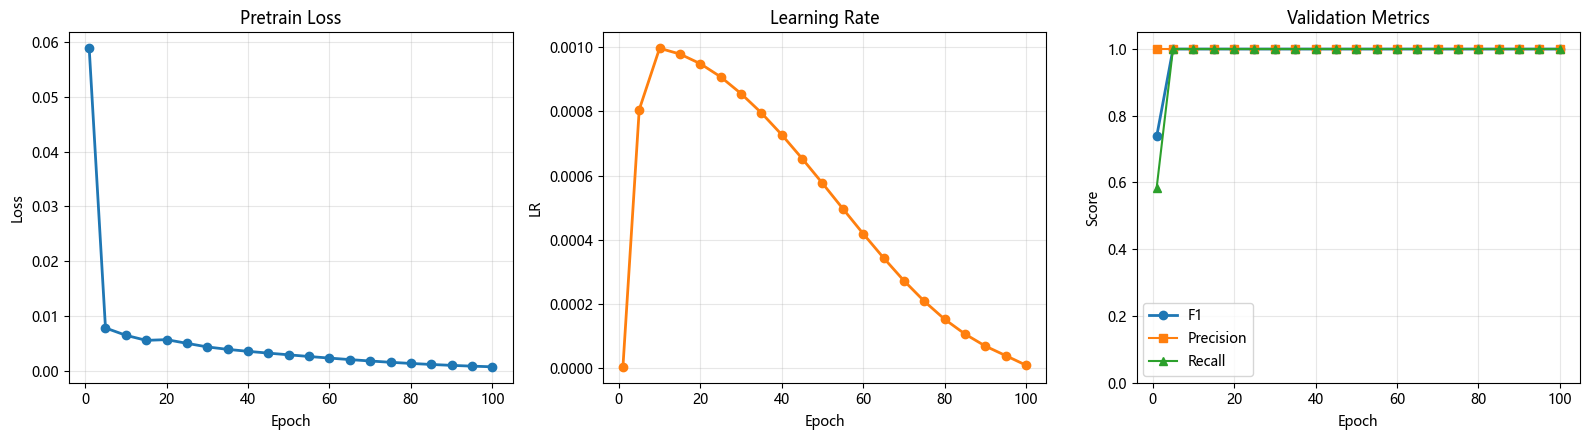

[save] 图已保存: e:\zhuomian\Bullying\scripts\output\visualizations\finetune_curves_20260325_205140.png


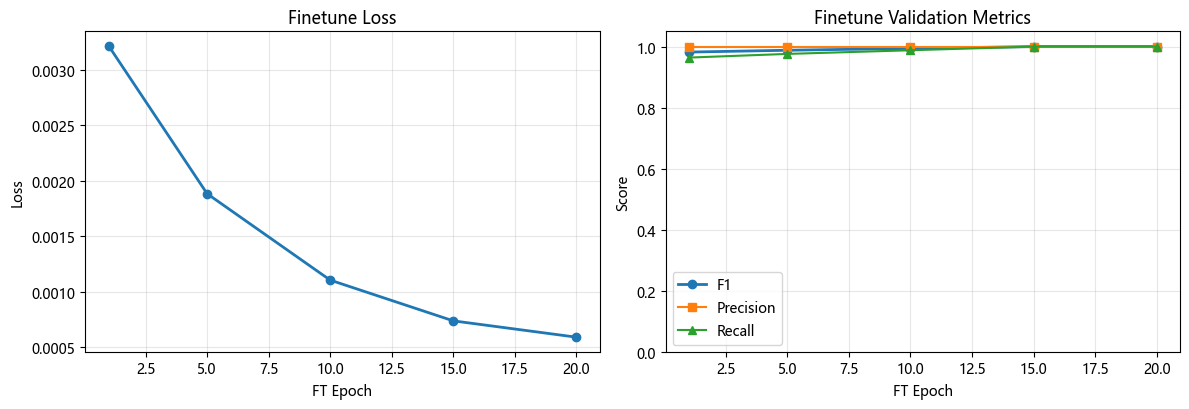

数据概览:
  audio_mel.npy: shape=(800, 1, 64, 128), dtype=float32
  radar_X.npy  : shape=(800, 5, 64), dtype=float32
  radar_y.npy  : shape=(800,), 类别分布={0: 600, 1: 200}
[save] 图已保存: e:\zhuomian\Bullying\scripts\output\visualizations\dataset_views_20260325_205141.png


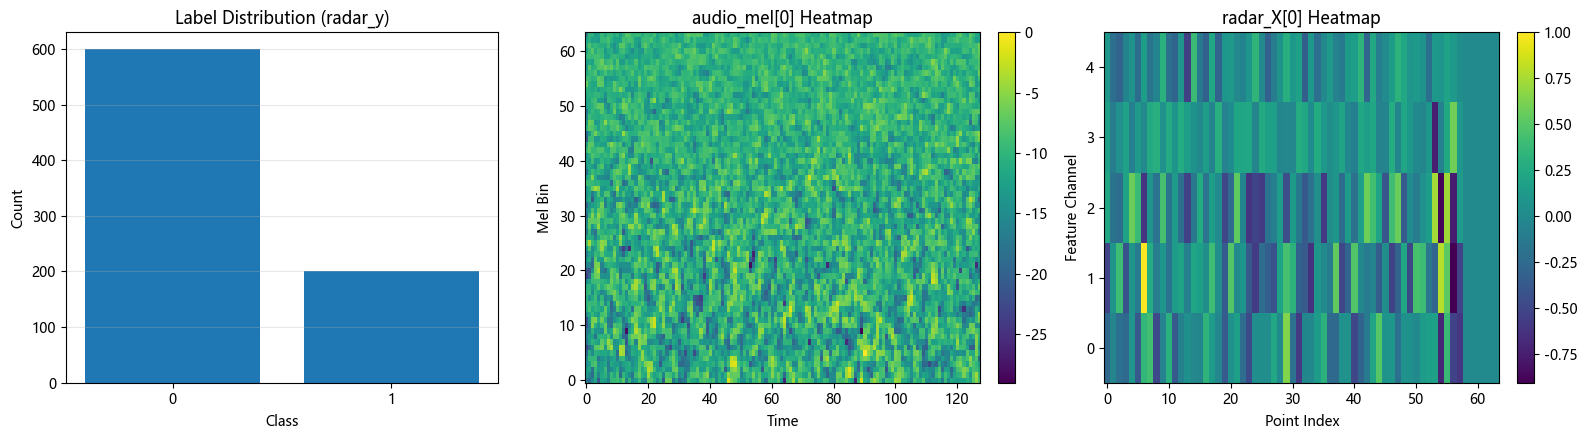

In [3]:
# Cell 10: 可视化脚本（云端/本地自适应 + 自动保存图片）
import os
import re
import sys
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print('[setup] matplotlib 未安装，正在自动安装...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib'])
    import matplotlib.pyplot as plt

# 尝试使用更清晰的中文字体（若环境无该字体会自动回退）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


# ===== 路径自动发现 =====
def first_existing_file(candidates):
    for p in candidates:
        if p and Path(p).is_file():
            return str(Path(p).resolve())
    return None


def first_existing_dir(candidates):
    for p in candidates:
        if p and Path(p).is_dir():
            return str(Path(p).resolve())
    return None


cwd = Path.cwd()

# 训练日志候选路径（本地 + 云端）
log_candidates = [
    cwd / '../logs/train_log.txt',
    cwd / './logs/train_log.txt',
    cwd / 'logs/train_log.txt',
    '/home/ma-user/work/logs/train_log.txt',
    '/home/ma-user/work/code/logs/train_log.txt',
    '/cache/logs/train_log.txt',
]
LOG_PATH = first_existing_file(log_candidates)

# 数据目录候选（本地 data / 云端预处理目录）
data_dir_candidates = [
    cwd / '../data',
    cwd / './data',
    cwd / 'data',
    '/home/ma-user/work/data',
    '/home/ma-user/work/code/data',
    '/home/ma-user/work/Ascend_Processed_Data',
    '/cache/data',
]
DATA_DIR = first_existing_dir(data_dir_candidates)

AUDIO_PATH = str(Path(DATA_DIR) / 'audio_mel.npy') if DATA_DIR else None
RADAR_X_PATH = str(Path(DATA_DIR) / 'radar_X.npy') if DATA_DIR else None
RADAR_Y_PATH = str(Path(DATA_DIR) / 'radar_y.npy') if DATA_DIR else None

# 图片输出目录候选（优先写到 output/visualizations）
out_dir_candidates = [
    cwd / './output/visualizations',
    cwd / '../output/visualizations',
    '/home/ma-user/work/output/visualizations',
    '/cache/output/visualizations',
]
SAVE_DIR = Path(out_dir_candidates[0])
for p in out_dir_candidates:
    try:
        Path(p).mkdir(parents=True, exist_ok=True)
        SAVE_DIR = Path(p)
        break
    except Exception:
        continue

print(f'[path] CWD       : {cwd}')
print(f'[path] LOG_PATH  : {LOG_PATH if LOG_PATH else "未找到"}')
print(f'[path] DATA_DIR  : {DATA_DIR if DATA_DIR else "未找到"}')
print(f'[path] SAVE_DIR  : {SAVE_DIR}')


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def _save_fig(fig, name):
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    out_path = SAVE_DIR / f'{name}_{ts}.png'
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    print(f'[save] 图已保存: {out_path}')


def parse_train_log(log_path):
    pre = {'epoch': [], 'loss': [], 'lr': [], 'f1': [], 'p': [], 'r': []}
    ft = {'epoch': [], 'loss': [], 'f1': [], 'p': [], 'r': []}

    if not log_path or not os.path.exists(log_path):
        print(f'[warn] 未找到训练日志: {log_path}')
        return pre, ft

    with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read()

    pre_pat = re.compile(
        r"Epoch\[\s*(\d+)\s*/\s*\d+\]\s*loss=([0-9eE+\-.]+)\s*lr=([0-9eE+\-.]+)\s*val_F1=([0-9eE+\-.]+)\s*P=([0-9eE+\-.]+)\s*R=([0-9eE+\-.]+)"
    )
    for m in pre_pat.finditer(text):
        pre['epoch'].append(int(m.group(1)))
        pre['loss'].append(_safe_float(m.group(2)))
        pre['lr'].append(_safe_float(m.group(3)))
        pre['f1'].append(_safe_float(m.group(4)))
        pre['p'].append(_safe_float(m.group(5)))
        pre['r'].append(_safe_float(m.group(6)))

    ft_pat = re.compile(
        r"FT\s*Epoch\[\s*(\d+)\s*/\s*\d+\]\s*loss=([0-9eE+\-.]+)\s*val_F1=([0-9eE+\-.]+)\s*P=([0-9eE+\-.]+)\s*R=([0-9eE+\-.]+)"
    )
    for m in ft_pat.finditer(text):
        ft['epoch'].append(int(m.group(1)))
        ft['loss'].append(_safe_float(m.group(2)))
        ft['f1'].append(_safe_float(m.group(3)))
        ft['p'].append(_safe_float(m.group(4)))
        ft['r'].append(_safe_float(m.group(5)))

    return pre, ft


def plot_pretrain_curves(pre):
    if len(pre['epoch']) == 0:
        print('[info] 未解析到预训练 epoch 记录，跳过预训练曲线。')
        return

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].plot(pre['epoch'], pre['loss'], marker='o', linewidth=2)
    axes[0].set_title('Pretrain Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(pre['epoch'], pre['lr'], marker='o', linewidth=2, color='tab:orange')
    axes[1].set_title('Learning Rate')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('LR')
    axes[1].grid(alpha=0.3)

    axes[2].plot(pre['epoch'], pre['f1'], marker='o', linewidth=2, label='F1')
    axes[2].plot(pre['epoch'], pre['p'], marker='s', linewidth=1.5, label='Precision')
    axes[2].plot(pre['epoch'], pre['r'], marker='^', linewidth=1.5, label='Recall')
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title('Validation Metrics')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Score')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    _save_fig(fig, 'pretrain_curves')
    plt.show()


def plot_finetune_curves(ft):
    if len(ft['epoch']) == 0:
        print('[info] 未解析到微调 epoch 记录，跳过微调曲线。')
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    axes[0].plot(ft['epoch'], ft['loss'], marker='o', linewidth=2)
    axes[0].set_title('Finetune Loss')
    axes[0].set_xlabel('FT Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(ft['epoch'], ft['f1'], marker='o', linewidth=2, label='F1')
    axes[1].plot(ft['epoch'], ft['p'], marker='s', linewidth=1.5, label='Precision')
    axes[1].plot(ft['epoch'], ft['r'], marker='^', linewidth=1.5, label='Recall')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('Finetune Validation Metrics')
    axes[1].set_xlabel('FT Epoch')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    _save_fig(fig, 'finetune_curves')
    plt.show()


def plot_dataset_views(audio_path, radar_x_path, radar_y_path):
    has_audio = bool(audio_path) and os.path.exists(audio_path)
    has_radar_x = bool(radar_x_path) and os.path.exists(radar_x_path)
    has_radar_y = bool(radar_y_path) and os.path.exists(radar_y_path)

    if not (has_audio or has_radar_x or has_radar_y):
        print('[info] 未找到 data 下可视化文件，跳过数据可视化。')
        return

    audio = np.load(audio_path) if has_audio else None
    radar_x = np.load(radar_x_path) if has_radar_x else None
    radar_y = np.load(radar_y_path) if has_radar_y else None

    print('数据概览:')
    if audio is not None:
        print(f'  audio_mel.npy: shape={audio.shape}, dtype={audio.dtype}')
    if radar_x is not None:
        print(f'  radar_X.npy  : shape={radar_x.shape}, dtype={radar_x.dtype}')
    if radar_y is not None:
        unique, counts = np.unique(radar_y, return_counts=True)
        print(f'  radar_y.npy  : shape={radar_y.shape}, 类别分布={dict(zip(unique.tolist(), counts.tolist()))}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    if radar_y is not None:
        unique, counts = np.unique(radar_y, return_counts=True)
        axes[0].bar([str(x) for x in unique], counts)
        axes[0].set_title('Label Distribution (radar_y)')
        axes[0].set_xlabel('Class')
        axes[0].set_ylabel('Count')
        axes[0].grid(axis='y', alpha=0.3)
    else:
        axes[0].set_title('Label Distribution')
        axes[0].text(0.5, 0.5, 'radar_y.npy 不存在', ha='center', va='center')
        axes[0].set_axis_off()

    if audio is not None:
        sample = audio[0]
        if sample.ndim == 3:
            sample = sample[0]
        im = axes[1].imshow(sample, aspect='auto', origin='lower')
        axes[1].set_title('audio_mel[0] Heatmap')
        axes[1].set_xlabel('Time')
        axes[1].set_ylabel('Mel Bin')
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    else:
        axes[1].set_title('audio_mel Heatmap')
        axes[1].text(0.5, 0.5, 'audio_mel.npy 不存在', ha='center', va='center')
        axes[1].set_axis_off()

    if radar_x is not None:
        rs = radar_x[0]
        if rs.ndim == 3:
            rs = rs[-1]
        im2 = axes[2].imshow(rs, aspect='auto', origin='lower')
        axes[2].set_title('radar_X[0] Heatmap')
        axes[2].set_xlabel('Point Index')
        axes[2].set_ylabel('Feature Channel')
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    else:
        axes[2].set_title('radar_X Heatmap')
        axes[2].text(0.5, 0.5, 'radar_X.npy 不存在', ha='center', va='center')
        axes[2].set_axis_off()

    plt.tight_layout()
    _save_fig(fig, 'dataset_views')
    plt.show()


pretrain_hist, finetune_hist = parse_train_log(LOG_PATH)
print(f"解析到预训练记录: {len(pretrain_hist['epoch'])} 条")
print(f"解析到微调记录  : {len(finetune_hist['epoch'])} 条")

plot_pretrain_curves(pretrain_hist)
plot_finetune_curves(finetune_hist)
plot_dataset_views(AUDIO_PATH, RADAR_X_PATH, RADAR_Y_PATH)